### Data Reference
https://spamassassin.apache.org/old/publiccorpus/

In [ ]:
#cd /content/drive/Shareddrives/Text/mail

[Errno 2] No such file or directory: '/content/drive/Shareddrives/Text/mail'
/content


### Download Data

In [1]:
# !wget "https://spamassassin.apache.org/old/publiccorpus/20021010_spam.tar.bz2"

--2024-09-28 03:48:54--  https://spamassassin.apache.org/old/publiccorpus/20021010_spam.tar.bz2
Resolving spamassassin.apache.org (spamassassin.apache.org)... 151.101.2.132, 2a04:4e42::644
Connecting to spamassassin.apache.org (spamassassin.apache.org)|151.101.2.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1192582 (1.1M) [application/x-bzip2]
Saving to: ‘20021010_spam.tar.bz2’

20021010_spam.tar.b 100%[===================>]   1.14M  --.-KB/s    in 0.04s   

2024-09-28 03:48:54 (28.3 MB/s) - ‘20021010_spam.tar.bz2’ saved [1192582/1192582]



In [2]:
#!wget "https://spamassassin.apache.org/old/publiccorpus/20021010_easy_ham.tar.bz2"

--2024-09-28 03:48:54--  https://spamassassin.apache.org/old/publiccorpus/20021010_easy_ham.tar.bz2
Resolving spamassassin.apache.org (spamassassin.apache.org)... 151.101.2.132, 2a04:4e42::644
Connecting to spamassassin.apache.org (spamassassin.apache.org)|151.101.2.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1677144 (1.6M) [application/x-bzip2]
Saving to: ‘20021010_easy_ham.tar.bz2’

20021010_easy_ham.t 100%[===================>]   1.60M  --.-KB/s    in 0.04s   

2024-09-28 03:48:55 (37.0 MB/s) - ‘20021010_easy_ham.tar.bz2’ saved [1677144/1677144]



In [ ]:
ls

20021010_easy_ham.tar.bz2  20021010_spam.tar.bz2  sample_data/


### untar the files

In [5]:
 #!tar -xjvf "20021010_spam.tar.bz2"

spam/
spam/0103.8c39bfed2079f865e9dfb75f4416a468
spam/0107.f1d4194b57840ea6587b9a73ed88e075
spam/0012.7bc8e619ad0264979edce15083e70a02
spam/0114.c104ada3a249e1e1846c0cd156a303e9
spam/0118.4be8b50c2a818c62b62e70c4b5456113
spam/0121.772c3ccd1b6c1a2e0e2ec0356082c77b
spam/0125.44381546181fc6c5d7ea59e917f232c5
spam/0129.78a705ff6b3bde3395d067459e6e46e2
spam/0132.7ac2141ed9a163f934ac65b3f59a2a03
spam/0136.7e7d6adf293fa0a3dc56b3f796cf00d1
spam/0140.a2bb669eaf743ed123fca884a40cfbd4
spam/0143.260a940290dcb61f9327b224a368d4af
spam/0147.65cf30538f09402e4d1bd4aa91d9532a
spam/0016.f9c349935955e1ccc7626270da898445
spam/0154.e39fc51ffdb9c2ecd480ce972078aeaa
spam/0158.ff5dce5446d2ec91f0caffeffdd48852
spam/0161.00e60d1a3478f1ae99ff49fbd4b30605
spam/0165.6eedc001155da3cbd75a60eba2b19448
spam/0169.bc6e1356af0602fb96dd3f721fb17c48
spam/0172.e524e85cab354337018e1d0d2fc21ffd
spam/0176.70022adaab1a9dfe64ae7588ffa5add9
spam/0180.afdbcd7acb65828c217eea90ff92c3b0
spam/0183.4aaadeb40e3362e71e3e4aba15624e3a
spam/

In [7]:
 #!tar -xjvf "20021010_easy_ham.tar.bz2"

easy_ham/
easy_ham/1011.82f644586fced13704dd79e22c3d8fb9
easy_ham/1051.cf81a19208b703f18497a0d6fedb1f13
easy_ham/1091.0bade8676340d304cae87dad02efa8ce
easy_ham/1121.51f7e5e557bde451a6b36e527211ed04
easy_ham/1161.9bcd69bccfeb05378e3e36fa62b16f7d
easy_ham/0121.b475478456e52de66ef0b0fb501bbfd3
easy_ham/1231.9a7db322df8f2bdf4eeb2d589cb51e34
easy_ham/1271.1af7c90a1459165ff18d621de40239c5
easy_ham/1301.7d4abb56d43695d968aafd6f15f5bbb3
easy_ham/1341.91bc30d50566e71807217c8977f7a793
easy_ham/1381.3c5527db01789ad42005006ac2ed2fcc
easy_ham/1411.a455fcdcc40a1a29551cc0153a9450bf
easy_ham/1451.64eda615fc56b4bbfdce6291a59c12f4
easy_ham/1491.2e82a3803e51f420c6398d963052469f
easy_ham/1521.692de69e480a819f6d32578f93fca74b
easy_ham/0191.314e2f68086989044e631e347a03b979
easy_ham/0231.1bc071b16de2cc1e2adab334be65f7c6
easy_ham/0271.349d737f101674586c61996593772a63
easy_ham/0311.de3984f9da9dba841ba515681fa065a6
easy_ham/0351.a7381397d31e8511581dc5cd59f39959
easy_ham/0391.e1f15b5f5a6dbbb8cde6571055be3127
eas

### Read all the mails from spam and ham folders

In [1]:
import os
import pandas as pd

def load_data(data_dir):
    emails = []
    labels = []

    # Read all the spam emails
    spam_dir = os.path.join(data_dir, 'spam')
    for filename in os.listdir(spam_dir):
        with open(os.path.join(spam_dir, filename), 'r', encoding='latin-1') as file:
            emails.append(file.read())
            labels.append(1)  # 1 for spam

    # Read all the ham (non-spam) emails
    ham_dir = os.path.join(data_dir, 'easy_ham')
    for filename in os.listdir(ham_dir):
        with open(os.path.join(ham_dir, filename), 'r', encoding='latin-1') as file:
            emails.append(file.read())
            labels.append(0)  # 0 for ham

    return pd.DataFrame({'email': emails, 'label': labels})


In [3]:
data_dir = '.'  # Set your directory path

In [4]:
df = load_data(data_dir)
# Check the dataset
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: './spam'

In [13]:
df.columns

Index(['email', 'label'], dtype='object')

In [14]:
df.label.value_counts()

,count
label,
0,2551
1,501


### Shuffle the mails

In [15]:
# Shuffle the DataFrame
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Save the shuffled DataFrame to a CSV file
df_shuffled.to_csv('email_data.csv', index=False)

# Check if the shuffling and saving worked
print(df_shuffled.head())

                                               email  label
0  From free_hgh304@eudoramail.com  Wed Sep 18 11...      1
1  From exmh-workers-admin@redhat.com  Mon Aug 26...      0
2  From exmh-workers-admin@redhat.com  Wed Sep 11...      0
3  Return-Path: skip@pobox.com\nDelivery-Date: Fr...      0
4  Replied: Tue, 17 Sep 2002 17:50:28 +0100\nRepl...      0


### Email cleaning steps

In [16]:
import re
import pandas as pd
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download NLTK resources (if not already installed)
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

# Initialize the Lemmatizer and stop words list
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Function to clean the email content
def clean_email(text):
    # 1. Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()

    # 2. Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)

    # 3. Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # 4. Remove numbers and special characters (keep words and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 5. Convert to lowercase
    text = text.lower()

    # 6. Tokenization
    tokens = word_tokenize(text)

    # 7. Remove stop words and short words
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]

    # 8. Lemmatization (reducing words to their base form)
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join tokens back into a single string
    return ' '.join(tokens)

# Apply the cleaning function to the email column
df['cleaned_email'] = df['email'].apply(clean_email)

# Check the cleaned data
print(df[['email', 'cleaned_email']].head())


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


                                               email  \
0  From martin_francis7@yahoo.fr  Sun Sep  8 14:4...   
1  From firstever001@44yes.onlineisbest.com  Mon ...   
2  From belakosaxxxmeb13mxy@aol.com  Sat Sep 14 1...   
3  From ilug-admin@linux.ie  Tue Sep 10 18:15:29 ...   
4  From FreeSoftware-5265v80@yahoo.com  Mon Aug 2...   

                                       cleaned_email  
0  sun sep returnpath deliveredto received localh...  
1  mon sep returnpath deliveredto received localh...  
2  sat sep returnpath deliveredto received localh...  
3  tue sep returnpath deliveredto received localh...  
4  mon aug returnpath deliveredto received localh...  


Stats Before Cleaning:
Average Character Count: 4149.72
Average Word Count: 434.48
Average Unique Word Count: 256.73

Stats After Cleaning:
Average Character Count: 1882.39
Average Word Count: 211.15
Average Unique Word Count: 138.49


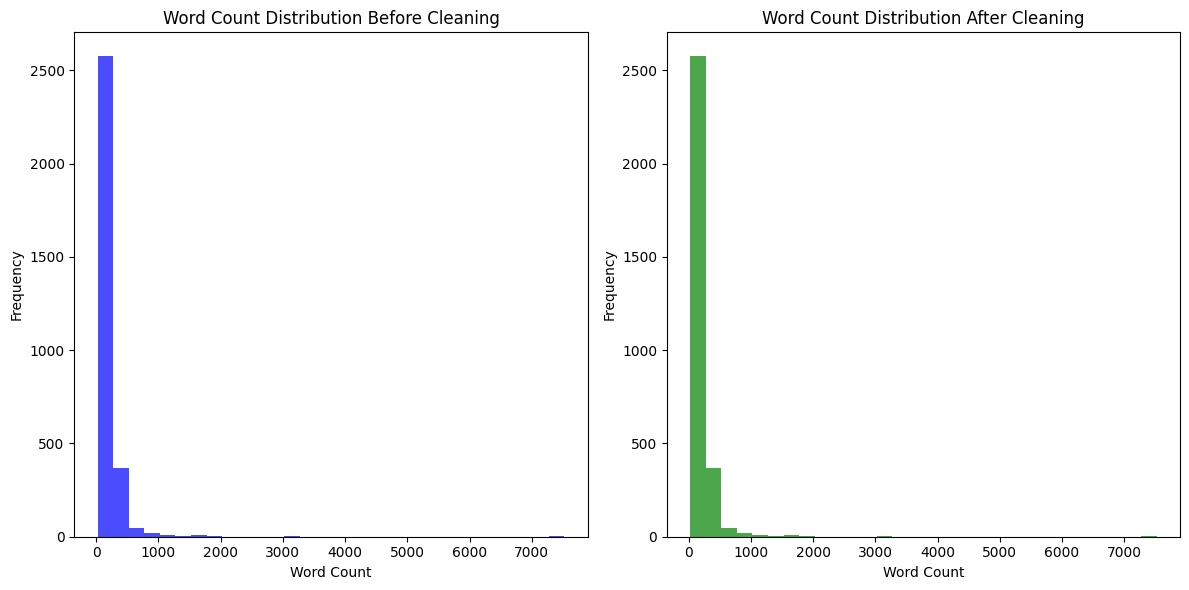

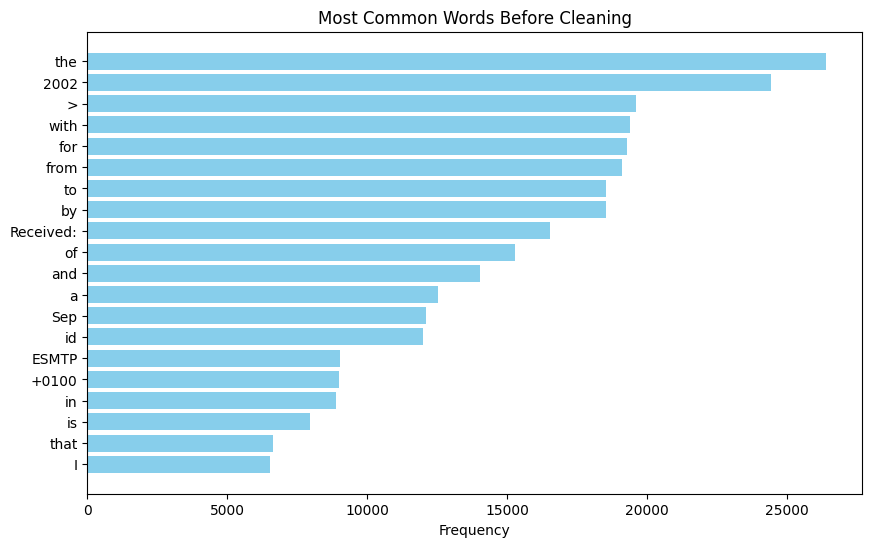

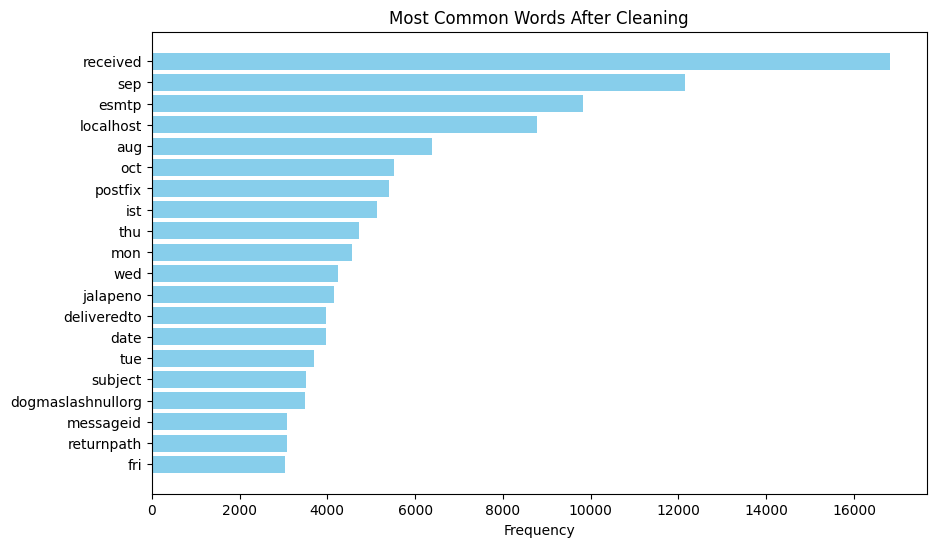

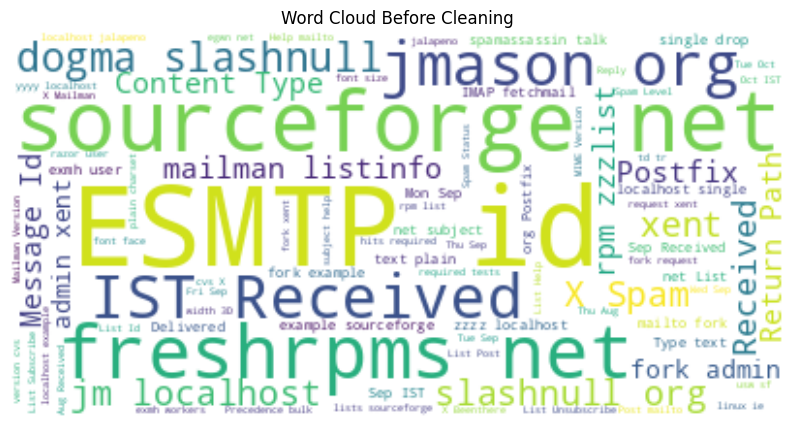

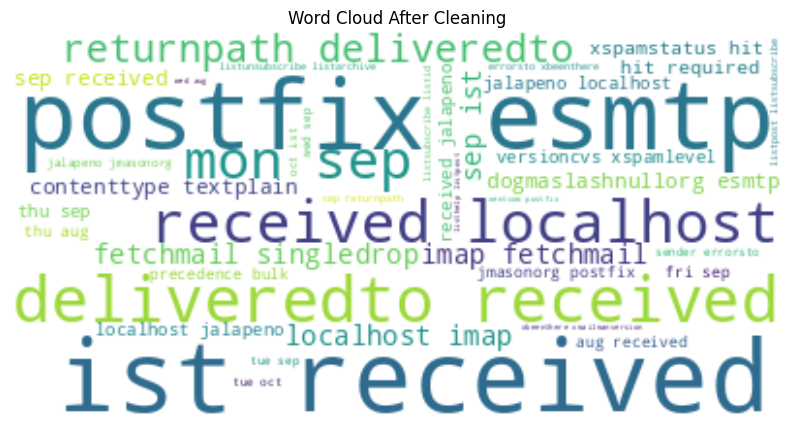

In [17]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

# Function to calculate basic statistics of the email text
def email_stats(df, column):
    df['char_count'] = df[column].apply(len)
    df['word_count'] = df[column].apply(lambda x: len(x.split()))
    df['unique_word_count'] = df[column].apply(lambda x: len(set(x.split())))

    print(f"Average Character Count: {df['char_count'].mean():.2f}")
    print(f"Average Word Count: {df['word_count'].mean():.2f}")
    print(f"Average Unique Word Count: {df['unique_word_count'].mean():.2f}")

    return df

# Analyze before cleaning
print("Stats Before Cleaning:")
df_before_cleaning = email_stats(df, 'email')

# Analyze after cleaning
print("\nStats After Cleaning:")
df_after_cleaning = email_stats(df, 'cleaned_email')

# Plot histograms for word count comparison
plt.figure(figsize=(12, 6))

# Word count before cleaning
plt.subplot(1, 2, 1)
plt.hist(df_before_cleaning['word_count'], bins=30, color='blue', alpha=0.7)
plt.title('Word Count Distribution Before Cleaning')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

# Word count after cleaning
plt.subplot(1, 2, 2)
plt.hist(df_after_cleaning['word_count'], bins=30, color='green', alpha=0.7)
plt.title('Word Count Distribution After Cleaning')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Function to plot the most common words
def plot_most_common_words(text_data, title, top_n=20):
    word_counts = Counter(" ".join(text_data).split())
    most_common_words = word_counts.most_common(top_n)

    words, counts = zip(*most_common_words)

    plt.figure(figsize=(10, 6))
    plt.barh(words, counts, color='skyblue')
    plt.xlabel('Frequency')
    plt.title(title)
    plt.gca().invert_yaxis()  # Invert y-axis to show highest word at top
    plt.show()

# Most common words before cleaning
plot_most_common_words(df_before_cleaning['email'], 'Most Common Words Before Cleaning')

# Most common words after cleaning
plot_most_common_words(df_after_cleaning['cleaned_email'], 'Most Common Words After Cleaning')

# Generate WordCloud before cleaning
wordcloud_before = WordCloud(background_color='white', max_words=100).generate(" ".join(df_before_cleaning['email']))
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_before, interpolation='bilinear')
plt.axis("off")
plt.title('Word Cloud Before Cleaning')
plt.show()

# Generate WordCloud after cleaning
wordcloud_after = WordCloud(background_color='white', max_words=100).generate(" ".join(df_after_cleaning['cleaned_email']))
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_after, interpolation='bilinear')
plt.axis("off")
plt.title('Word Cloud After Cleaning')
plt.show()


### Handling Word Frequency

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=3000, stop_words='english', ngram_range=(1, 2))

# Fit and transform the cleaned email content
X_tfidf = tfidf_vectorizer.fit_transform(df['cleaned_email'])

# Convert to a DataFrame for easier manipulation (optional)
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Show a sample of the TF-IDF features
print(tfidf_df.head())


   ability  able  absolutely  abuse  accept  accepted  access  according  \
0      0.0   0.0         0.0    0.0     0.0       0.0     0.0        0.0   
1      0.0   0.0         0.0    0.0     0.0       0.0     0.0        0.0   
2      0.0   0.0         0.0    0.0     0.0       0.0     0.0        0.0   
3      0.0   0.0         0.0    0.0     0.0       0.0     0.0        0.0   
4      0.0   0.0         0.0    0.0     0.0       0.0     0.0        0.0   

    account  achieve  ...  youd  youll  young  youre  youve  zawodny  zero  \
0  0.151441      0.0  ...   0.0    0.0    0.0    0.0    0.0      0.0   0.0   
1  0.000000      0.0  ...   0.0    0.0    0.0    0.0    0.0      0.0   0.0   
2  0.000000      0.0  ...   0.0    0.0    0.0    0.0    0.0      0.0   0.0   
3  0.454464      0.0  ...   0.0    0.0    0.0    0.0    0.0      0.0   0.0   
4  0.000000      0.0  ...   0.0    0.0    0.0    0.0    0.0      0.0   0.0   

   zzzzasonorg  zzzzasonorg postfix  zzzzteana  
0     0.030786           

Handling Sender Information

In [ ]:
df = pd.read_csv('email_data.csv')

In [ ]:
df.head()

In [19]:
import pandas as pd
from email import message_from_string
# Function to extract headers from raw email text
def extract_email_headers(raw_email):
    # Parse the email content into a message object
    msg = message_from_string(raw_email)

    # Extract relevant headers
    headers = {
        'From': msg['From'],
        'To': msg['To'],
        'Subject': msg['Subject'],
        'Date': msg['Date'],
        'Reply-To': msg['Reply-To'],
        'Message-ID': msg['Message-ID']
    }
    return headers

Store Headers in a DataFrame

In [20]:
# Apply the extraction function to the email content and create new columns
df['From'] = df['email'].apply(lambda x: extract_email_headers(x)['From'])
df['To'] = df['email'].apply(lambda x: extract_email_headers(x)['To'])
df['Subject'] = df['email'].apply(lambda x: extract_email_headers(x)['Subject'])
df['Date'] = df['email'].apply(lambda x: extract_email_headers(x)['Date'])
df['Reply-To'] = df['email'].apply(lambda x: extract_email_headers(x)['Reply-To'])
df['Message-ID'] = df['email'].apply(lambda x: extract_email_headers(x)['Message-ID'])

Analyze Sender and Receiver Information

In [21]:
# Extract domain from 'From' email addresses (if available)
df['from_domain'] = df['From'].apply(lambda x: x.split('@')[-1] if pd.notnull(x) and '@' in x else 'unknown')

# Most common senders
most_common_senders = df['From'].value_counts().head(10)
print("Most common senders:")
print(most_common_senders)

# Most common sender domains
most_common_sender_domains = df['from_domain'].value_counts().head(10)
print("\nMost common sender domains:")
print(most_common_sender_domains)

# Similar analysis can be done for 'To' field
df['to_domain'] = df['To'].apply(lambda x: x.split('@')[-1] if pd.notnull(x) and '@' in x else 'unknown')
most_common_receiver_domains = df['to_domain'].value_counts().head(10)
print("\nMost common receiver domains:")
print(most_common_receiver_domains)


Most common senders:
From
boingboing <rssfeeds@example.com>      114
guardian <rssfeeds@example.com>        100
newscientist <rssfeeds@example.com>     79
fark <rssfeeds@example.com>             70
gamasutra <rssfeeds@example.com>        58
Tom <tomwhore@slack.net>                57
pudge@perl.org                          56
scripting <rssfeeds@example.com>        55
diveintomark <rssfeeds@example.com>     48
tim.one@comcast.net (Tim Peters)        45
Name: count, dtype: int64

Most common sender domains:
from_domain
example.com>                642
hotmail.com>                 84
slack.net>                   57
perl.org                     56
comcast.net (Tim Peters)     45
canada.com>                  44
barrera.org>                 43
yahoo.com>                   40
shipwright.com>              40
egwn.net>                    36
Name: count, dtype: int64

Most common receiver domains:
to_domain
example.com                 1062
freshrpms.net                226
example.com>            

Use Headers for Feature Engineering in Spam Detection

In [ ]:
# Example: Creating a numerical feature for sender frequency
df['sender_frequency'] = df.groupby('From')['From'].transform('count')

# # One-hot encode the sender domains
# from_domain_ohe = pd.get_dummies(df['from_domain'], prefix='from_domain')
# df = pd.concat([df, from_domain_ohe], axis=1)

# These header features can now be used alongside email content features (like word frequency or TF-IDF)


Code to Extract Only the Body (Remove Headers)

In [22]:
!pip install chardet

In [23]:
import chardet

def extract_email_body(raw_email):
    msg = message_from_string(raw_email)
    body = ""

    if msg.is_multipart():
        for part in msg.walk():
            # Prioritize plain text content
            if part.get_content_type() == "text/plain":
                body_bytes = part.get_payload(decode=True)
                encoding = chardet.detect(body_bytes)['encoding']  # Detect encoding
                body = body_bytes.decode(encoding, errors='ignore') # Decode with detected encoding
                break
            # Fall back to HTML if no plain text is found
            elif part.get_content_type() == "text/html":
                body_bytes = part.get_payload(decode=True)
                encoding = chardet.detect(body_bytes)['encoding']  # Detect encoding
                body = body_bytes.decode(encoding, errors='ignore') # Decode with detected encoding
    else:
        body_bytes = msg.get_payload(decode=True)
        encoding = chardet.detect(body_bytes)['encoding']  # Detect encoding
        body = body_bytes.decode(encoding, errors='ignore') # Decode with detected encoding


    return body

In [24]:
# Apply the function to extract only the body and create a new 'email_body' column
df['email_body'] = df['email'].apply(extract_email_body)

# Now df['email_body'] will contain the content without headers
print(df[['email_body']].head())

                                          email_body
0  MR MARTIN FRANCIS\nABIDJAN COTE D’IVOIRE\nWEST...
1  Protect your financial well-being.\nPurchase a...
2  <HTML>\n<BODY>\n<meta http-equiv="Content-Type...
3  Dear Partner to be,\n\nFirst, I must apologise...
4  <html>\n<head>\n<title>Digital Publishing Tool...


In [25]:
df.head()

,email,label,cleaned_email,char_count,word_count,unique_word_count,From,To,Subject,Date,Reply-To,Message-ID,from_domain,to_domain,email_body
0,From martin_francis7@yahoo.fr Sun Sep 8 14:4...,1,sun sep returnpath deliveredto received localh...,3238,415,286,=?iso-8859-1?q?ackou=20acke=20martin=20francis...,zzzz@jmason.org,I NEED AN URGENT CAPABLE ASSISTANCE.TEL:+225 0...,"Sun, 8 Sep 2002 15:29:20 +0200 (CEST)",None,<20020908132920.1093.qmail@web14407.mail.yahoo...,yahoo.fr>,jmason.org,MR MARTIN FRANCIS\nABIDJAN COTE D’IVOIRE\nWEST...
1,From firstever001@44yes.onlineisbest.com Mon ...,1,mon sep returnpath deliveredto received localh...,943,130,87,firstever001@44yes.onlineisbest.com,skyogppeif@onlineisbest.com,ADV: Extended Auto Warranties Here iubrq,"Mon, 23 Sep 2002 09:55:53 -0400",firstever001@44yes.onlineisbest.com,<200209231355.g8NDtro27632@44yes.onlineisbest....,44yes.onlineisbest.com,onlineisbest.com,Protect your financial well-being.\nPurchase a...
2,From belakosaxxxmeb13mxy@aol.com Sat Sep 14 1...,1,sat sep returnpath deliveredto received localh...,738,95,72,belakosaxxxmeb13mxy@aol.com,Katherine@nodots-daemon.zzzzason.org,eBay PowerSeller Secrets ...,"Sat, 14 Sep 2002 08:19:51 -0400",belakosaxxxmeb13mxy@aol.com,<00003d963754$00005924$00001aaa@210.39.240.216>,aol.com,nodots-daemon.zzzzason.org,"<HTML>\n<BODY>\n<meta http-equiv=""Content-Type..."
3,From ilug-admin@linux.ie Tue Sep 10 18:15:29 ...,1,tue sep returnpath deliveredto received localh...,2677,335,238,"""Eseimoku K.Anderson(Chief)"" <k_u2_1999@consul...",<ilug@linux.ie>,[ILUG] Seeking Your Partnership,"Tue, 10 Sep 2002 16:17:30 +0200",None,<20020910151323.EA86D7003F@relay.dub-t3-1.nwcg...,consultant.com>,linux.ie>,"Dear Partner to be,\n\nFirst, I must apologise..."
4,From FreeSoftware-5265v80@yahoo.com Mon Aug 2...,1,mon aug returnpath deliveredto received localh...,1357,181,127,"""Free Publishing Software"" <FreeSoftware-5265v...",<zzzz@example.com>,Take your Marketing to the Next Level,"Mon, 26 Aug 2002 19:24:06 +0100","""Free Publishing Software"" <FreeSoftware-5265v...",<004b12e28d1a$4347d2b7$3ce68ab0@sgcrua>,yahoo.com>,example.com>,<html>\n<head>\n<title>Digital Publishing Tool...


In [26]:
df.columns

Index(['email', 'label', 'cleaned_email', 'char_count', 'word_count',
       'unique_word_count', 'From', 'To', 'Subject', 'Date', 'Reply-To',
       'Message-ID', 'from_domain', 'to_domain', 'email_body'],
      dtype='object')

In [27]:
# # Replace the 'email' column with 'email_body' if you only want the body content
# df['email'] = df['email_body']
# df.drop(columns=['email_body'], inplace=True)

# # Save the cleaned data to a CSV or use it for further analysis
# df.to_csv("cleaned_emails.csv", index=False)

Analyze Subject Line

In [28]:
# Feature: Length of the subject
df['subject_length'] = df['Subject'].apply(lambda x: len(x) if pd.notnull(x) else 0)

# Feature: Number of exclamation marks in the subject
df['subject_exclamations'] = df['Subject'].apply(lambda x: x.count('!') if pd.notnull(x) else 0)

# Feature: Whether the subject starts with "ADV"
df['subject_adv'] = df['Subject'].apply(lambda x: 1 if pd.notnull(x) and x.upper().startswith("ADV") else 0)

Time-Based Features (from Date)

* Extract the hour, day of the week, or month from the Date field.

* Create a binary feature for whether the email was sent during working hours (e.g., 9 am to 5 pm).

In [32]:
import dateutil
# Define a mapping of time zone abbreviations to their UTC offsets
tzinfos = {
    'EDT': -4 * 3600,  # Eastern Daylight Time: UTC-4
    'EST': -5 * 3600,  # Eastern Standard Time: UTC-5
    'GMT': 0,          # GMT: UTC+0
    'PST': -8 * 3600,  # Pacific Standard Time: UTC-8
    'CST': -6 * 3600,  # Central Standard Time: UTC-6
    'MST': -7 * 3600,  # Mountain Standard Time: UTC-7
    'UT': 0,           # Universal Time: UTC+0
    'CDT': -5 * 3600,  # Central Daylight Time: UTC-5
}

# Function to clean the date string and parse with tzinfos
def clean_date_string(date_str):
    if pd.isnull(date_str):
        return None

    # Clean up common long-form time zones (e.g., "Eastern Daylight Time")
    date_str = re.sub(r'(Eastern Daylight Time|Eastern Standard Time|Pacific Standard Time)',
                      lambda match: 'EDT' if 'Daylight' in match.group() else 'EST', date_str)

    # Attempt to parse with timezone information
    try:
        return dateutil.parser.parse(date_str, tzinfos=tzinfos)
    except (ValueError, TypeError):
        return None

# Apply the function to clean and parse the date
df['parsed_date'] = df['Date'].apply(clean_date_string)

In [33]:
df['parsed_date'].head()

,parsed_date
0,2002-09-08 15:29:20+02:00
1,2002-09-23 09:55:53-04:00
2,2002-09-14 08:19:51-04:00
3,2002-09-10 16:17:30+02:00
4,2002-08-26 19:24:06+01:00


In [34]:

# Feature: Extract hour of the day
df['email_hour'] = df['parsed_date'].apply(lambda x: x.hour if pd.notnull(x) else -1)

# Feature: Extract day of the week (0=Monday, 6=Sunday)
df['email_dayofweek'] = df['parsed_date'].apply(lambda x: x.weekday() if pd.notnull(x) else -1)

# Feature: Whether the email was sent during working hours (9am-6pm)
df['working_hours'] = df['email_hour'].apply(lambda x: 1 if 9 <= x <= 18 else 0)


The Message-ID can be analyzed to see if it's coming from legitimate sources or dynamically generated by spammers

In [35]:
# Feature: Length of the Message-ID
df['message_id_length'] = df['Message-ID'].apply(lambda x: len(x) if pd.notnull(x) else 0)

# Feature: Extract the domain part of the Message-ID
df['message_id_domain'] = df['Message-ID'].apply(lambda x: x.split('@')[-1] if pd.notnull(x) and '@' in x else 'unknown')


The Reply-To header is often used in phishing and spam emails to direct replies to a different address

In [36]:
# Check if 'Reply-To' is different from 'From'
df['reply_to_different'] = df.apply(lambda x: 1 if pd.notnull(x['Reply-To']) and x['Reply-To'] != x['From'] else 0, axis=1)

# Extract domain from 'Reply-To'
df['reply_to_domain'] = df['Reply-To'].apply(lambda x: x.split('@')[-1] if pd.notnull(x) and '@' in x else 'unknown')


In [ ]:
# Example: Combining header features with content features (like TF-IDF)
# Assuming 'content_features' is a DataFrame of word-based features (e.g., TF-IDF)

# Concatenate all features into one DataFrame
final_features = pd.concat([df[['subject_length', 'subject_exclamations', 'subject_adv',
                                'email_hour', 'email_dayofweek', 'working_hours',
                                'message_id_length', 'reply_to_different']],
                            content_features], axis=1)

# Proceed with model training using the final features


In [37]:
df['Subject'].isnull().sum()

1

In [38]:
# Replace NaN values in 'Subject' and 'Body' with an empty string
df['Subject'] = df['Subject'].fillna('')

In [39]:
df['email_body'].isnull().sum()

0

In [40]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Combine Subject and Body into a single field
df['combined_text'] = df['Subject'] + " " + df['email_body']

# Initialize the TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the combined text into TF-IDF features
tfidf_matrix = tfidf_vectorizer.fit_transform(df['combined_text'])

# Convert TF-IDF matrix into a DataFrame for easier interpretation
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Output the resulting TF-IDF DataFrame
print(tfidf_df)


            00       000  0000  00000    000000  000000000  00000254  00001  \
0     0.013047  0.036883   0.0    0.0  0.000000        0.0       0.0    0.0   
1     0.000000  0.043684   0.0    0.0  0.000000        0.0       0.0    0.0   
2     0.000000  0.000000   0.0    0.0  0.000000        0.0       0.0    0.0   
3     0.000000  0.000000   0.0    0.0  0.000000        0.0       0.0    0.0   
4     0.000000  0.000000   0.0    0.0  0.013765        0.0       0.0    0.0   
...        ...       ...   ...    ...       ...        ...       ...    ...   
3047  0.000000  0.000000   0.0    0.0  0.000000        0.0       0.0    0.0   
3048  0.000000  0.000000   0.0    0.0  0.000000        0.0       0.0    0.0   
3049  0.000000  0.000000   0.0    0.0  0.000000        0.0       0.0    0.0   
3050  0.000000  0.000000   0.0    0.0  0.000000        0.0       0.0    0.0   
3051  0.000000  0.000000   0.0    0.0  0.000000        0.0       0.0    0.0   

      00002  00003  ...  허락없이  헤어디자이너   현재  호황을  홈쇼

In [41]:
# Example: Combining header features with tfidf_df features (like TF-IDF)

# Concatenate all features into one DataFrame
final_features = pd.concat([df[['subject_length', 'subject_exclamations', 'subject_adv',
                                'email_hour', 'email_dayofweek', 'working_hours',
                                'message_id_length', 'reply_to_different']],
                            tfidf_df], axis=1)

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(final_features, df['label'], test_size=0.2, random_state=42)

# Define a simple neural network
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Binary classification (spam vs ham)

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Make predictions
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Evaluate the model performance
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"F1 Score: {f1}")

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.7966 - loss: 0.4707 - val_accuracy: 0.8478 - val_loss: 0.3288
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.9032 - loss: 0.2320 - val_accuracy: 0.9558 - val_loss: 0.1161
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.9881 - loss: 0.0671 - val_accuracy: 0.9836 - val_loss: 0.0501
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - accuracy: 0.9991 - loss: 0.0167 - val_accuracy: 0.9885 - val_loss: 0.0321
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 1.0000 - loss: 0.0090 - val_accuracy: 0.9918 - val_loss: 0.0227
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 0.9902 - val_loss: 0.0198
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 0.9902 - val_loss: 0.0198
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9902 - 

In [43]:
pwd

'/content'

In [44]:
# Save the model to disk
model.save('spam_classifier_model.h5')

# Load the model
from tensorflow.keras.models import load_model
loaded_model = load_model('spam_classifier_model.h5')

# Predict on new data using the loaded model
new_predictions = (loaded_model.predict(X_test) > 0.5).astype(int)


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [45]:
df.head()

,email,label,cleaned_email,char_count,word_count,unique_word_count,From,To,Subject,Date,...,subject_adv,parsed_date,email_hour,email_dayofweek,working_hours,message_id_length,message_id_domain,reply_to_different,reply_to_domain,combined_text
0,From martin_francis7@yahoo.fr Sun Sep 8 14:4...,1,sun sep returnpath deliveredto received localh...,3238,415,286,=?iso-8859-1?q?ackou=20acke=20martin=20francis...,zzzz@jmason.org,I NEED AN URGENT CAPABLE ASSISTANCE.TEL:+225 0...,"Sun, 8 Sep 2002 15:29:20 +0200 (CEST)",...,0,2002-09-08 15:29:20+02:00,15,6,1,51,web14407.mail.yahoo.com>,0,unknown,I NEED AN URGENT CAPABLE ASSISTANCE.TEL:+225 0...
1,From firstever001@44yes.onlineisbest.com Mon ...,1,mon sep returnpath deliveredto received localh...,943,130,87,firstever001@44yes.onlineisbest.com,skyogppeif@onlineisbest.com,ADV: Extended Auto Warranties Here iubrq,"Mon, 23 Sep 2002 09:55:53 -0400",...,1,2002-09-23 09:55:53-04:00,9,0,1,50,44yes.onlineisbest.com>,0,44yes.onlineisbest.com,ADV: Extended Auto Warranties Here iubrq Prote...
2,From belakosaxxxmeb13mxy@aol.com Sat Sep 14 1...,1,sat sep returnpath deliveredto received localh...,738,95,72,belakosaxxxmeb13mxy@aol.com,Katherine@nodots-daemon.zzzzason.org,eBay PowerSeller Secrets ...,"Sat, 14 Sep 2002 08:19:51 -0400",...,0,2002-09-14 08:19:51-04:00,8,5,0,47,210.39.240.216>,0,aol.com,eBay PowerSeller Secrets ...
3,From ilug-admin@linux.ie Tue Sep 10 18:15:29 ...,1,tue sep returnpath deliveredto received localh...,2677,335,238,"""Eseimoku K.Anderson(Chief)"" <k_u2_1999@consul...",<ilug@linux.ie>,[ILUG] Seeking Your Partnership,"Tue, 10 Sep 2002 16:17:30 +0200",...,0,2002-09-10 16:17:30+02:00,16,1,1,55,relay.dub-t3-1.nwcgroup.com>,0,unknown,[ILUG] Seeking Your Partnership Dear Partner t...
4,From FreeSoftware-5265v80@yahoo.com Mon Aug 2...,1,mon aug returnpath deliveredto received localh...,1357,181,127,"""Free Publishing Software"" <FreeSoftware-5265v...",<zzzz@example.com>,Take your Marketing to the Next Level,"Mon, 26 Aug 2002 19:24:06 +0100",...,0,2002-08-26 19:24:06+01:00,19,0,0,39,sgcrua>,0,yahoo.com>,Take your Marketing to the Next Level <html>\n...


In [46]:
# Save the shuffled DataFrame to a CSV file
df.to_csv('cleaned_spamassassin_data.csv', index=False)

In [47]:
# prompt: show newpredictions

print(new_predictions)


[[1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
